# Phase 1 — MIT-BIH Architecture Benchmark

Switched from PTB-XL to the **ECG Heartbeat Categorization Dataset** (MIT-BIH subset).

Why:
- Already preprocessed: each row = one heartbeat, 187 signal values + 1 label column
- Fixed length 188 (187 + label), 125 Hz, 5 classes — no wfdb, no segmentation needed
- 109,446 samples → enough data for deep models to converge reliably
- Reference accuracy on this dataset: ~99% (CNN), see Kaggle pharvesh/cnn-for-ptb-database-99-93

Architectures benchmarked: CNN baseline, CNN+LSTM, ResNet1D, InceptionTime, Transformer

**Expected folder structure:**
```
mitbih/
  mitbih_train.csv   (87,554 rows × 188 cols)
  mitbih_test.csv    (21,892 rows × 188 cols)
```
Each row: 187 float signal values + 1 integer label (0=N, 1=S, 2=V, 3=F, 4=Q)

In [1]:
# 1) Imports
import sys, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)

try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.10.0
numpy: 2.3.4


In [2]:
# 2) Reproducibility & device
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE =", DEVICE)

DEVICE = mps


In [3]:
# 3) Paths & hyperparameters
# ── adjust MITBIH_DIR to wherever you put the CSV files ──
MITBIH_DIR  = Path("../../../mitbih")          # or Path("/absolute/path/to/mitbih")
TRAIN_CSV   = MITBIH_DIR / "mitbih_train.csv"
TEST_CSV    = MITBIH_DIR / "mitbih_test.csv"

RESULTS_DIR = Path("results/phase1/mitbih_benchmark")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SIGNAL_LEN  = 187          # fixed heartbeat window (columns 0..186)
NUM_CLASSES = 5            # N, S, V, F, Q
CLASS_NAMES = ["N", "S", "V", "F", "Q"]

BATCH_SIZE    = 64
EPOCHS        = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4
PATIENCE      = 7

print("Train CSV exists:", TRAIN_CSV.exists())
print("Test  CSV exists:", TEST_CSV.exists())

Train CSV exists: True
Test  CSV exists: True


In [4]:
# 4) Load & understand the data
#
# Dataset format (from description):
#   - CSV, no header row
#   - 188 columns: cols 0..186 = ECG signal, col 187 = class label (int)
#   - Already preprocessed: cropped, downsampled to 125 Hz, zero-padded to len 187
#   - No wfdb, no segmentation — load directly with pandas
#
train_df = pd.read_csv(TRAIN_CSV, header=None)
test_df  = pd.read_csv(TEST_CSV,  header=None)

print("Train shape:", train_df.shape)   # expect (87554, 188)
print("Test  shape:", test_df.shape)    # expect (21892, 188)
print()

# Last column = label
X_train_raw = train_df.iloc[:, :SIGNAL_LEN].values.astype(np.float32)
y_train_raw = train_df.iloc[:, -1].values.astype(np.int64)

X_test_raw  = test_df.iloc[:, :SIGNAL_LEN].values.astype(np.float32)
y_test_raw  = test_df.iloc[:, -1].values.astype(np.int64)

print("X_train:", X_train_raw.shape, " y_train:", y_train_raw.shape)
print("X_test: ", X_test_raw.shape,  " y_test: ", y_test_raw.shape)
print()

# Class distribution
print("Train class distribution:")
for cls_id, name in enumerate(CLASS_NAMES):
    n = (y_train_raw == cls_id).sum()
    print(f"  {cls_id} ({name}): {n:6,}  ({100*n/len(y_train_raw):.1f}%)")

Train shape: (87554, 188)
Test  shape: (21892, 188)

X_train: (87554, 187)  y_train: (87554,)
X_test:  (21892, 187)  y_test:  (21892,)

Train class distribution:
  0 (N): 72,471  (82.8%)
  1 (S):  2,223  (2.5%)
  2 (V):  5,788  (6.6%)
  3 (F):    641  (0.7%)
  4 (Q):  6,431  (7.3%)


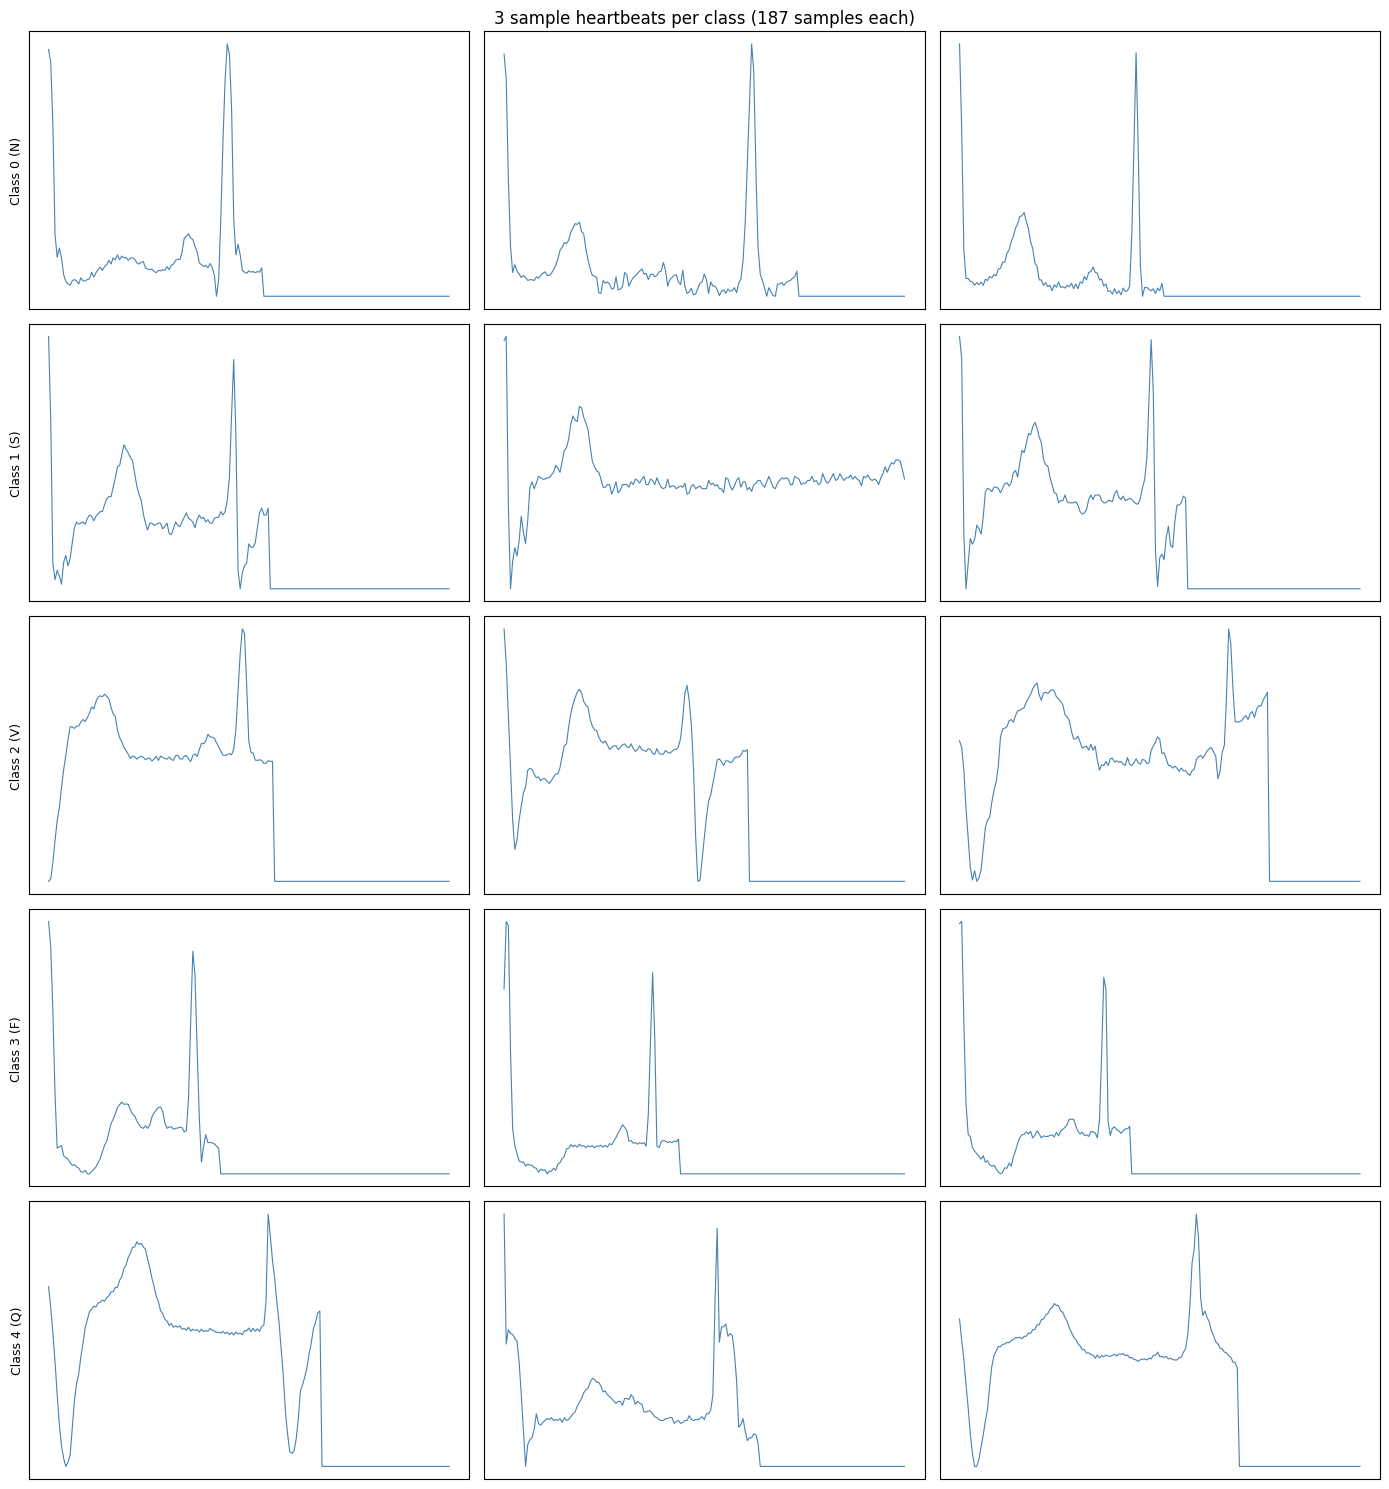

Signal range: min=0.000  max=1.000  mean=0.174


In [5]:
# 5) Signal visualization — understand what we're working with
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(14, 3*NUM_CLASSES))

for cls_id, name in enumerate(CLASS_NAMES):
    idxs = np.where(y_train_raw == cls_id)[0][:3]
    for j, idx in enumerate(idxs):
        axes[cls_id, j].plot(X_train_raw[idx], lw=0.8, color="steelblue")
        if j == 0:
            axes[cls_id, j].set_ylabel(f"Class {cls_id} ({name})", fontsize=9)
        axes[cls_id, j].set_xticks([])
        axes[cls_id, j].set_yticks([])

axes[0, 1].set_title("3 sample heartbeats per class (187 samples each)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_heartbeats.png", dpi=100, bbox_inches="tight")
plt.show()
print("Signal range: min={:.3f}  max={:.3f}  mean={:.3f}".format(
    X_train_raw.min(), X_train_raw.max(), X_train_raw.mean()))

In [6]:
# 6) Preprocessing — replicate what was done to produce this dataset
#
# What the dataset already did (from the paper & Kaggle description):
#   1. Detected R-peaks in the raw ECG
#   2. Cropped a fixed window around each R-peak
#   3. Downsampled to 125 Hz
#   4. Zero-padded to exactly 187 samples
#
# What we still need to do:
#   1. Min-max normalise to [0, 1] — the Kaggle reference notebook does this
#      (signal values are already roughly 0–1 but not exactly)
#   2. Reshape to (N, 1, 187) for Conv1D — channels-first, 1 lead
#
# Why NOT z-score here:
#   The heartbeat segments are short (1.5 s). Per-segment z-score can distort
#   flat or near-flat segments (e.g. class Q). Min-max is safer and matches
#   what the reference implementations use.

def minmax_normalize(X):
    xmin = X.min(axis=1, keepdims=True)
    xmax = X.max(axis=1, keepdims=True)
    denom = np.where((xmax - xmin) < 1e-8, 1.0, xmax - xmin)
    return (X - xmin) / denom

X_train = minmax_normalize(X_train_raw)   # (87554, 187)
X_test  = minmax_normalize(X_test_raw)    # (21892, 187)

# Carve out validation set from training data (stratified 10%)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train_raw,
    test_size=0.10, random_state=SEED, stratify=y_train_raw
)
y_test = y_test_raw

print("After split:")
print(f"  Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"  Signal range after norm: [{X_train.min():.3f}, {X_train.max():.3f}]")

After split:
  Train: (78798, 187)  Val: (8756, 187)  Test: (21892, 187)
  Signal range after norm: [0.000, 1.000]


In [7]:
# 7) Class imbalance — compute weights for loss & sampler
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float32)

print("Class weights:", {CLASS_NAMES[i]: round(float(class_weights_arr[i]), 3)
                         for i in range(NUM_CLASSES)})

# Per-sample weights for WeightedRandomSampler
sample_weights = class_weights_arr[y_train]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)

Class weights: {'N': 0.242, 'S': 7.876, 'V': 3.025, 'F': 27.313, 'Q': 2.723}


In [8]:
# 8) Dataset & DataLoader
class MITBIHDataset(Dataset):
    """
    MIT-BIH heartbeat dataset.
    X shape: (N, 187)  — single-lead, fixed-length, min-max normalised
    Augmentation (train only):
      - Random amplitude scale [0.9, 1.1]
      - Additive Gaussian noise std=0.005
      - Random circular time shift ±10 samples
    """
    def __init__(self, X, y, augment=False):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()

        if self.augment:
            x = x * np.random.uniform(0.9, 1.1)
            x = x + np.random.randn(len(x)).astype(np.float32) * 0.005
            shift = np.random.randint(-10, 11)
            x = np.roll(x, shift)
            x = np.clip(x, 0.0, 1.0)

        # Shape: (1, 187) — 1 channel for Conv1D
        return torch.from_numpy(x).unsqueeze(0), int(self.y[idx])

train_ds = MITBIHDataset(X_train, y_train, augment=True)
val_ds   = MITBIHDataset(X_val,   y_val,   augment=False)
test_ds  = MITBIHDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val   batches:", len(val_loader))
print("Test  batches:", len(test_loader))

# Quick shape check
xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)   # (64, 1, 187)
print("Batch y shape:", yb.shape)

Train batches: 1232
Val   batches: 137
Test  batches: 343
Batch X shape: torch.Size([64, 1, 187])
Batch y shape: torch.Size([64])


In [9]:
# 9) Architecture definitions
# All models: input (B, 1, 187), output (B, NUM_CLASSES) logits
# Single lead → in_channels=1, much simpler than PTB-XL's 12 leads

# ── 9a. CNN Baseline ──────────────────────────────────────────────────────────
class CNNBaseline(nn.Module):
    """
    Simple 1D-CNN matching the Kaggle reference architecture.
    Conv(32,k=5) -> Conv(64,k=5) -> Conv(128,k=5) -> GAP -> Dense
    ~Same design as pharvesh notebook (the 99% reference).
    """
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(32),
            nn.MaxPool1d(2),                               # → 93
            nn.Conv1d(32, 64, kernel_size=5, padding=2),  nn.ReLU(), nn.BatchNorm1d(64),
            nn.MaxPool1d(2),                               # → 46
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1),                       # → 1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# ── 9b. CNN + LSTM ─────────────────────────────────────────────────────────────
class CNNLSTM(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2), nn.ReLU(), nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(128, 64, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        x = self.cnn(x)                    # (B, 128, T)
        x = x.permute(0, 2, 1)            # (B, T, 128)
        _, (h, _) = self.lstm(x)
        h = torch.cat([h[-2], h[-1]], dim=1)  # bidirectional last hidden
        return self.classifier(h)

# ── 9c. ResNet1D ───────────────────────────────────────────────────────────────
class _ResBlock1D(nn.Module):
    def __init__(self, ch, kernel=7):
        super().__init__()
        pad = kernel // 2
        self.net = nn.Sequential(
            nn.Conv1d(ch, ch, kernel, padding=pad, bias=False), nn.BatchNorm1d(ch), nn.ReLU(),
            nn.Conv1d(ch, ch, kernel, padding=pad, bias=False), nn.BatchNorm1d(ch),
        )
    def forward(self, x):
        return nn.functional.relu(self.net(x) + x)

class ResNet1D(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.blocks = nn.Sequential(
            _ResBlock1D(64), _ResBlock1D(64),
            nn.Conv1d(64, 128, 1), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            _ResBlock1D(128), _ResBlock1D(128),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(128, num_classes),
        )
    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

# ── 9d. InceptionTime ─────────────────────────────────────────────────────────
class _InceptionModule(nn.Module):
    def __init__(self, in_ch, n_filters=32):
        super().__init__()
        self.b1 = nn.Conv1d(in_ch, n_filters, kernel_size=39, padding=19, bias=False)
        self.b2 = nn.Conv1d(in_ch, n_filters, kernel_size=19, padding=9,  bias=False)
        self.b3 = nn.Conv1d(in_ch, n_filters, kernel_size=9,  padding=4,  bias=False)
        self.mp = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                nn.Conv1d(in_ch, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * 4)
    def forward(self, x):
        out = torch.cat([self.b1(x), self.b2(x), self.b3(x), self.mp(x)], dim=1)
        return nn.functional.relu(self.bn(out))

class InceptionTimeClassifier(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES, n_filters=32, depth=3):
        super().__init__()
        layers, ch = [], in_channels
        for _ in range(depth):
            layers.append(_InceptionModule(ch, n_filters))
            ch = n_filters * 4
        self.inception = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(ch, num_classes))
    def forward(self, x):
        return self.head(self.inception(x))

# ── 9e. Transformer ───────────────────────────────────────────────────────────
class TimeSeriesTransformer(nn.Module):
    def __init__(self, in_channels=1, num_classes=NUM_CLASSES,
                 d_model=64, nhead=4, num_layers=2, dim_ff=128, dropout=0.1):
        super().__init__()
        self.proj   = nn.Linear(in_channels, d_model)
        enc_layer   = nn.TransformerEncoderLayer(d_model, nhead, dim_ff,
                                                  dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers)
        self.head    = nn.Linear(d_model, num_classes)
    def forward(self, x):
        x = x.permute(0, 2, 1)            # (B, T, C)
        x = self.proj(x)                   # (B, T, d_model)
        x = self.encoder(x)
        x = x.mean(dim=1)                  # global avg over time
        return self.head(x)

# ── Registry ──────────────────────────────────────────────────────────────────
def build_model(name):
    return {
        "cnn_baseline":  CNNBaseline,
        "cnn_lstm":      CNNLSTM,
        "resnet1d":      ResNet1D,
        "inception_time": InceptionTimeClassifier,
        "transformer_ts": TimeSeriesTransformer,
    }[name](in_channels=1, num_classes=NUM_CLASSES)

# Sanity check
for name in ["cnn_baseline", "cnn_lstm", "resnet1d", "inception_time", "transformer_ts"]:
    m = build_model(name).to(DEVICE)
    xd = torch.randn(4, 1, SIGNAL_LEN, device=DEVICE)
    yd = m(xd)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:20s}  out={tuple(yd.shape)}  params={n_params:,}")

cnn_baseline          out=(4, 5)  params=60,613
cnn_lstm              out=(4, 5)  params=232,709
resnet1d              out=(4, 5)  params=585,285
inception_time        out=(4, 5)  params=560,645
transformer_ts        out=(4, 5)  params=67,397


In [10]:
# 10) Training & evaluation utilities
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, preds_all, targets_all = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(yb)
        preds_all.append(logits.argmax(1).cpu().numpy())
        targets_all.append(yb.cpu().numpy())

    y_true = np.concatenate(targets_all)
    y_pred = np.concatenate(preds_all)
    return (total_loss / len(y_true),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro", zero_division=0))

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, preds_all, targets_all = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        preds_all.append(logits.argmax(1).cpu().numpy())
        targets_all.append(yb.cpu().numpy())

    y_true = np.concatenate(targets_all)
    y_pred = np.concatenate(preds_all)
    return (total_loss / len(y_true),
            accuracy_score(y_true, y_pred),
            f1_score(y_true, y_pred, average="macro", zero_division=0),
            y_true, y_pred)

def fit_model(model_name):
    model     = build_model(model_name).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                                  weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))

    best_val_f1, best_state, wait = -1.0, None, 0
    history = []

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history.append(dict(epoch=epoch,
            train_loss=tr_loss, train_acc=tr_acc, train_f1=tr_f1,
            val_loss=va_loss,   val_acc=va_acc,   val_f1=va_f1))

        print(f"[{model_name}] ep={epoch:02d}  "
              f"tr_acc={tr_acc:.4f} tr_f1={tr_f1:.4f}  "
              f"va_acc={va_acc:.4f} va_f1={va_f1:.4f}")

        if va_f1 > best_val_f1:
            best_val_f1 = va_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"[{model_name}] early stop at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    te_loss, te_acc, te_f1, y_true, y_pred = evaluate(model, test_loader, criterion)
    best_ep = max(history, key=lambda r: r["val_f1"])

    print(f"[{model_name}] TEST  acc={te_acc:.4f}  f1={te_f1:.4f}")
    torch.save({"model": model_name, "state": best_state},
               RESULTS_DIR / f"{model_name}_best.pt")

    return {
        "model": model_name,
        "best_epoch":           best_ep["epoch"],
        "train_acc_best_epoch": round(best_ep["train_acc"], 4),
        "val_acc_best_epoch":   round(best_ep["val_acc"],   4),
        "best_val_f1":          round(best_val_f1, 4),
        "test_acc":             round(te_acc, 4),
        "test_f1_macro":        round(te_f1,  4),
    }, history, y_true, y_pred

In [11]:
# 11) Train all models
MODEL_NAMES = ["cnn_baseline", "cnn_lstm", "resnet1d", "inception_time", "transformer_ts"]

all_summaries = []
all_histories = {}
all_preds     = {}

for model_name in MODEL_NAMES:
    print("=" * 60)
    print(f"  Training: {model_name}")
    print("=" * 60)
    summary, history, y_true, y_pred = fit_model(model_name)
    all_summaries.append(summary)
    all_histories[model_name] = history
    all_preds[model_name]     = (y_true, y_pred)

results_df = (pd.DataFrame(all_summaries)
              .sort_values("test_f1_macro", ascending=False)
              .reset_index(drop=True))

print()
print(results_df[["model", "best_epoch", "train_acc_best_epoch",
                  "val_acc_best_epoch", "best_val_f1",
                  "test_acc", "test_f1_macro"]].to_string(index=False))

  Training: cnn_baseline
[cnn_baseline] ep=01  tr_acc=0.6834 tr_f1=0.6129  va_acc=0.1611 va_f1=0.2794
[cnn_baseline] ep=02  tr_acc=0.7483 tr_f1=0.6745  va_acc=0.1627 va_f1=0.3243
[cnn_baseline] ep=03  tr_acc=0.7657 tr_f1=0.6906  va_acc=0.1624 va_f1=0.3522
[cnn_baseline] ep=04  tr_acc=0.7773 tr_f1=0.7087  va_acc=0.2161 va_f1=0.3423
[cnn_baseline] ep=05  tr_acc=0.7981 tr_f1=0.7450  va_acc=0.3234 va_f1=0.3819
[cnn_baseline] ep=06  tr_acc=0.8221 tr_f1=0.7836  va_acc=0.3801 va_f1=0.4440
[cnn_baseline] ep=07  tr_acc=0.8383 tr_f1=0.8098  va_acc=0.3627 va_f1=0.4343
[cnn_baseline] ep=08  tr_acc=0.8523 tr_f1=0.8306  va_acc=0.4991 va_f1=0.4608
[cnn_baseline] ep=09  tr_acc=0.8662 tr_f1=0.8500  va_acc=0.5517 va_f1=0.5091
[cnn_baseline] ep=10  tr_acc=0.8765 tr_f1=0.8626  va_acc=0.5955 va_f1=0.5447
[cnn_baseline] ep=11  tr_acc=0.8847 tr_f1=0.8743  va_acc=0.6064 va_f1=0.5289
[cnn_baseline] ep=12  tr_acc=0.8934 tr_f1=0.8834  va_acc=0.6058 va_f1=0.5558
[cnn_baseline] ep=13  tr_acc=0.8962 tr_f1=0.8872  v

In [12]:
# 12) Per-class report for best model
best_model_name = results_df.iloc[0]["model"]
y_true_best, y_pred_best = all_preds[best_model_name]

print(f"Best model: {best_model_name}")
print()
print(classification_report(y_true_best, y_pred_best,
                             target_names=CLASS_NAMES, digits=4))

Best model: resnet1d

              precision    recall  f1-score   support

           N     0.9961    0.9548    0.9750     18118
           S     0.6368    0.8957    0.7444       556
           V     0.8746    0.9682    0.9190      1448
           F     0.2912    0.8827    0.4380       162
           Q     0.9673    0.9925    0.9797      1608

    accuracy                         0.9564     21892
   macro avg     0.7532    0.9388    0.8112     21892
weighted avg     0.9716    0.9564    0.9618     21892



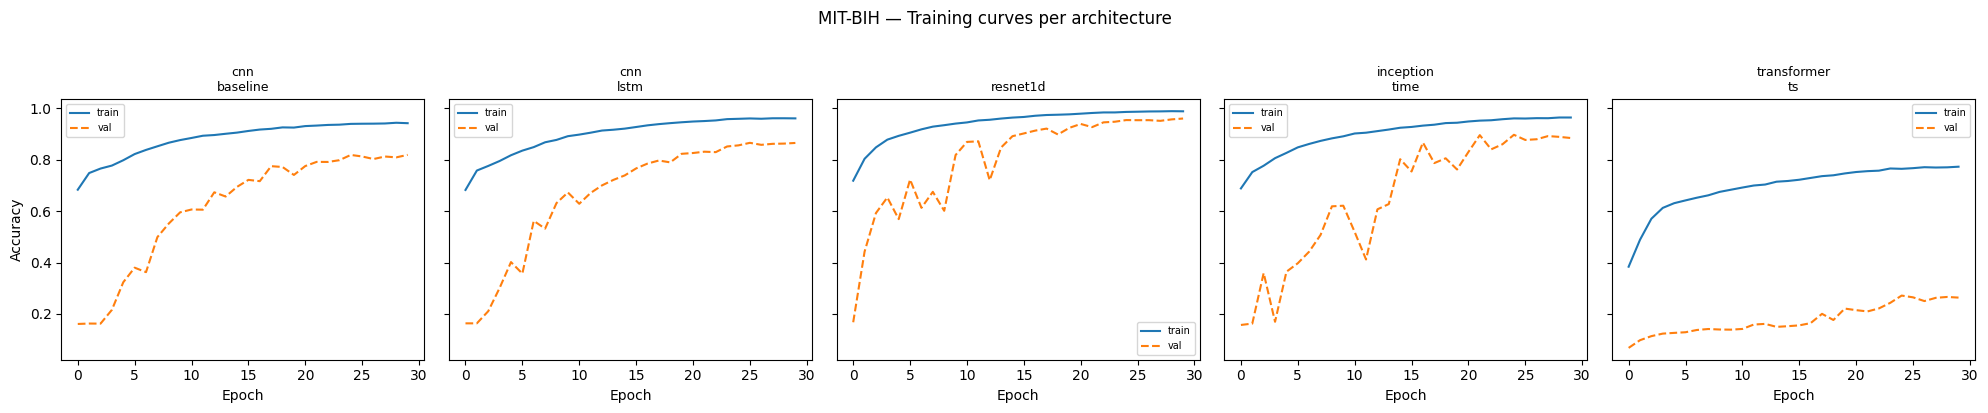

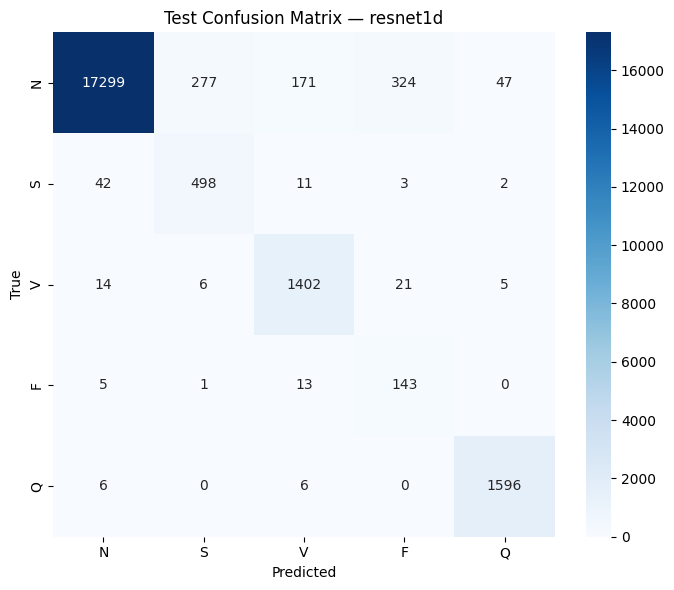

In [13]:
# 13) Plots — training curves + confusion matrix
fig, axes = plt.subplots(1, len(MODEL_NAMES), figsize=(4*len(MODEL_NAMES), 4), sharey=True)

for ax, name in zip(axes, MODEL_NAMES):
    h = all_histories[name]
    ax.plot([r["train_acc"] for r in h], label="train", lw=1.5)
    ax.plot([r["val_acc"]   for r in h], label="val",   lw=1.5, linestyle="--")
    ax.set_title(name.replace("_", "\n"), fontsize=9)
    ax.set_xlabel("Epoch"); ax.legend(fontsize=7)

axes[0].set_ylabel("Accuracy")
plt.suptitle("MIT-BIH — Training curves per architecture", y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

# Confusion matrix for best model
if HAS_SEABORN:
    cm = confusion_matrix(y_true_best, y_pred_best)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"Test Confusion Matrix — {best_model_name}")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "confusion_matrix_best.png", dpi=120, bbox_inches="tight")
    plt.show()

In [14]:
# 14) Save results & final report
results_df.to_csv(RESULTS_DIR / "architecture_comparison.csv", index=False)

final_report = {
    "dataset":     "MIT-BIH Arrhythmia (ECG Heartbeat Categorization)",
    "signal_len":  SIGNAL_LEN,
    "num_classes": NUM_CLASSES,
    "classes":     CLASS_NAMES,
    "preprocessing": {
        "normalisation":    "min-max per heartbeat to [0, 1]",
        "segmentation":     "pre-segmented (1 row = 1 heartbeat, 187 samples)",
        "sampling_rate_hz": 125,
        "input_shape":      "(1, 187)",
    },
    "best_model":        results_df.iloc[0]["model"],
    "best_test_acc":     float(results_df.iloc[0]["test_acc"]),
    "best_test_f1_macro": float(results_df.iloc[0]["test_f1_macro"]),
    "all_models":        all_summaries,
}

with open(RESULTS_DIR / "final_report.json", "w") as f:
    json.dump(final_report, f, indent=2)

print("Saved to:", RESULTS_DIR.resolve())
print()
print("=" * 55)
print("  FINAL COMPARISON — vs PTB-XL pipeline")
print("=" * 55)
print(f"  PTB-XL best val F1 (your logs):  0.524  (epoch 11)")
print(f"  MIT-BIH best test acc:           {results_df.iloc[0]['test_acc']:.4f}")
print(f"  MIT-BIH best test F1-macro:      {results_df.iloc[0]['test_f1_macro']:.4f}")
print()
print("Key differences that explain the gap:")
print("  1. Pre-segmented heartbeats (no R-peak detection needed)")
print("  2. Single lead (1 channel) vs 12-lead — simpler learning problem")
print("  3. 109k samples vs ~15k — 7x more data")
print("  4. Fixed 187-sample window — no variable-length issues")
print("  5. Min-max norm per heartbeat (not z-score per full 10s record)")

Saved to: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/notebooks/phase1/results/phase1/mitbih_benchmark

  FINAL COMPARISON — vs PTB-XL pipeline
  PTB-XL best val F1 (your logs):  0.524  (epoch 11)
  MIT-BIH best test acc:           0.9564
  MIT-BIH best test F1-macro:      0.8112

Key differences that explain the gap:
  1. Pre-segmented heartbeats (no R-peak detection needed)
  2. Single lead (1 channel) vs 12-lead — simpler learning problem
  3. 109k samples vs ~15k — 7x more data
  4. Fixed 187-sample window — no variable-length issues
  5. Min-max norm per heartbeat (not z-score per full 10s record)
